# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fatima12aa/fa-ml/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Question

**Research question:** Can a machine learning model, using verified search performance
signals (click-through rate and average search position), produce a more precise ranked
queue of pages requiring review than a hand-written rule using the same signals?

**The decision this supports:** Which pages a FlyRank content reviewer should prioritize
reviewing first, out of a large page inventory, when they have limited time and cannot
review every page individually.

**Unit of analysis:** One row = one content page, evaluated using its February 2026
performance signals (impressions, CTR, average position).

**The action a human takes:** A reviewer opens the ranked queue and works through it in
order, starting a title/meta review on the highest-priority flagged pages first.

**Cost of a wrong call:** Two-directional. Flagging a page that didn't need review wastes
reviewer time but causes no lasting harm. Missing a page that genuinely needed review risks
that page continuing to lose traffic silently — a more expensive mistake, since visibility
lost isn't always easy to recover (echoing the FlyRank paper's own finding on the value of
timely refresh).

**Why ML, not just a fixed rule:** Our Week 4 hand-written rule (a binary gate: good position
AND low CTR) achieved Precision@20 = 0.15, Precision@50 = 0.22. Restricting a Random Forest
model to the same two verified signals — but letting it learn graded relationships rather
than a strict AND-gate — improved this to Precision@20 = 0.25-0.35, Precision@50 = 0.16-0.32
(varying by validation split). This is genuine, evidence-based justification for using ML
here: the pattern (how CTR and position jointly relate to decline risk) was real but too
graded/nuanced for a simple hand-written threshold to fully capture. The model can output a continuous probability, while the hand written rule was just a binary gate giving hard coded 0 or 1.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

**Release used:** FlyRank's internship data warehouse (`FlyRank/internship-warehouse` on
Hugging Face), build `flyrank_pseudonymized_warehouse_release_v20260703`.

**Tables used:**
- `fact_content_daily_performance` — daily, page-level GSC performance signals (impressions,
  clicks, average position), filtered to February and March 2026.
- `dim_content` — static page-level characteristics (word count, search volume), used during
  exploratory feature testing.

**Date windows:** February 2026 (feature window) and March 2026 (label/outcome window) —
a mid-panel period chosen specifically to avoid the final month of the dataset (June 2026),
which would have no genuine "future" period available for safe label construction.

**What we excluded, and why (public-safe):**
- `trend_direction` / `trend_pct`: pre-built columns directly derived from the same
  month-over-month comparison we needed to predict — using them would be leakage (feeding
  the model the answer disguised as a feature).
- `march_impressions` and any March-window signal: excluded from features entirely, since
  March defines our label; only used to construct the label itself, never as model input.
- `provider_used` / `model_used`: 71.5% missing, with risk of confounding (correlation with
  decline may reflect *when* a tool was adopted, not genuine content quality).
- `ai_traffic_pct`: 93.6% of rows were exactly zero — too sparse to support reliable
  page-level claims.
- Rows lacking genuine GSC tracking (`gsc_data_available` = FALSE): excluded via SQL filter,
  since these are zero-filled placeholders, not real measurements.
- All client and content identifiers are pseudonymized hashes (`client_hash_id`,
  `content_hash_id`) — used only for joining and grouping (e.g. client-holdout validation),
  never as model features, and no raw client names, URLs, or private queries appear anywhere
  in this work.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

**Assumptions:**
- A page is labeled "declining" if its March 2026 impressions fall below 80% of its
  February 2026 impressions (a genuine 20%+ month-over-month drop). This threshold is a
  policy choice, not a universal rule — a stricter or looser cutoff would flag a different
  set of pages.
- We assume February performance data is representative enough to serve as a fair prediction
  window for March outcomes; we do not claim this generalizes to arbitrary other month pairs
  without re-validation.

**Label definition (one sentence):** `is_declining = 1` if a page's March 2026 impressions
are less than 80% of its February 2026 impressions, else `0`.

**Features used (final model):**
- `feb_ctr` — February click-through rate (clicks ÷ impressions)
- `feb_avg_position` — average February search ranking position

**Features deliberately left out of the final model** (tested earlier, found not to help):
`word_count`, `search_volume`, `feb_impressions` — an earlier 5-feature version of this model
gave `word_count` the highest feature importance, yet performed no better than the baseline
rule on a held-out test set. This is a caution about feature importance: high importance
during training does not guarantee real predictive value on unseen data. Restricting to only
the two features we had independently verified as meaningful (Section on Signal Audit, below)
produced a genuine improvement instead.

**Signal audit (verification before building the rule):**
- CTR vs. position: CONFIRMED. Pages ranked in the top 10 positions showed meaningfully
  higher CTR (mean 0.0061) than pages ranked 11-30 (0.0030) or 30+ (0.0024), across a large
  sample (n=151,956).
- Volume vs. decline: OPPOSITE of our original hypothesis. Higher-traffic pages showed LOWER
  decline rates (15.7%) than lower-traffic pages (22.4%) — a clean, monotonic pattern
  (n=134,238). This finding reshaped how volume was used: not as a standalone risk signal,
  but as a way to weigh the value of fixing an already-declining page.

**Baseline:** A transparent, hand-written rule: flag a page if its average February position
is ≤10 AND its February CTR is below 0.006083 (the mean CTR of top-10-position pages). This
is a fair comparison because it uses the exact same two verified signals as the final model,
differing only in that it applies a strict binary threshold rather than a learned, graded
relationship.

**Model:** Random Forest Classifier, trained on the two verified features only
(`feb_ctr`, `feb_avg_position`).

**Validation design:** Grouped by `client_hash_id` using `GroupShuffleSplit` (25% of clients
held out entirely for testing) — not a plain random row-level split. This matters because
pages from the same client may share client-specific patterns; a naive random split lets the
model partially "memorize" a client seen in training and inflates test performance. We
directly verified zero client overlap between train and test sets before trusting any result.

**Leakage checks performed:**
- Confirmed `is_declining` and `march_impressions` never appear among model features
  (verified programmatically via assertion, not just asserted in prose).
- Confirmed all dynamic features (`feb_ctr`, `feb_avg_position`) are built from SQL queries
  explicitly restricted to the February date range, with no March dates included.
- Confirmed pseudonymous IDs (`client_hash_id`, `content_hash_id`) are used only for joining
  and grouping, never as model features.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results (vs baseline)

**Base rate:** 15.9% of pages in our clean, leakage-free test set were genuinely declining
(the majority class, "not declining," is 84.1%). This matters because it sets the floor —
any method should be judged against how much it beats simply guessing the majority class,
not against 0 or 100%.

**Comparison table (same client-holdout test split, same metric):**

| Method | Precision@20 | Precision@50 |
|---|---|---|
| Baseline (hand-written rule) | 0.15 | 0.22 |
| Random Forest (verified features) | 0.25 | 0.32 |

**Stability check:** Re-running the grouped split with 5 different random seeds showed
Precision@20 ranging 0.25–0.35 and Precision@50 ranging 0.16–0.32. The model consistently
outperformed the baseline at K=20 across all seeds tested, but dipped slightly below baseline
at K=50 on one of five splits (0.16 vs. 0.22). We report this honestly rather than only
showing the most favorable run: the improvement is real and fairly consistent, but not
perfectly stable across every possible split.

**What the errors look like:** In an earlier 5-feature version of this model (before
restricting to verified signals only), `word_count` received the highest feature importance
(0.30–0.47 depending on method), yet that model failed to outperform the baseline
(Precision@20 = 0.10–0.15, no clear improvement). This is a meaningful negative result: high
feature importance during training did not translate into genuine predictive value on
held-out clients, reinforcing the value of grounding model features in independently
verified signals (our Signal Audit) rather than letting a model freely weight unverified
features.

Saved chart to work/figures/model_vs_baseline_precision.png


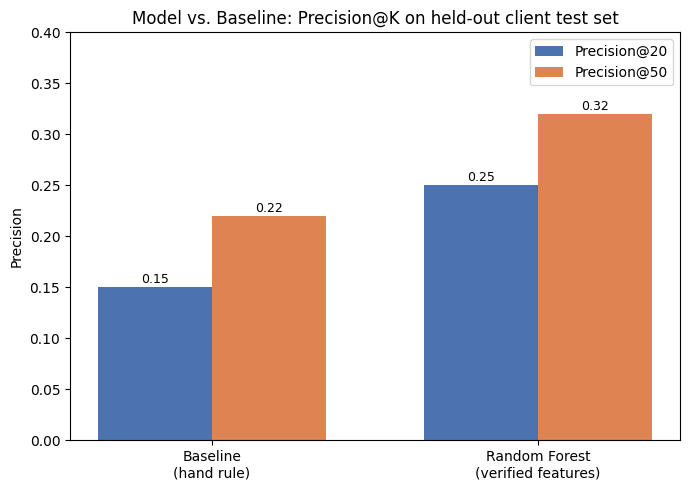

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Data from our results table
methods = ["Baseline\n(hand rule)", "Random Forest\n(verified features)"]
precision_20 = [0.15, 0.25]
precision_50 = [0.22, 0.32]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, precision_20, width, label="Precision@20", color="#4C72B0")
bars2 = ax.bar(x + width/2, precision_50, width, label="Precision@50", color="#DD8452")

ax.set_ylabel("Precision")
ax.set_title("Model vs. Baseline: Precision@K on held-out client test set")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 0.4)

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()

# Save to work/figures/ (this one DOES get committed, per w07's export rules)
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/model_vs_baseline_precision.png", dpi=150, bbox_inches="tight")
print("Saved chart to work/figures/model_vs_baseline_precision.png")

plt.show()

## 5. Limitations

*What this work cannot claim.*

## Limitations

**This is decision-support, not an autonomous system.** The ranked queue helps prioritize
human review; it does not verify itself and must not be treated as a final judgment. Our
Week 4 signal audit found real false positives even in a CONFIRMED signal (e.g., pages that
recently moved into a good position, whose low February CTR reflected an outdated ranking
rather than a genuine listing problem).

**Coverage limitation:** Our clean, leakage-free training set (75,189 pages) only covers
pages with genuine GSC tracking data in both February and March — in our slice, only 36.7%
of rows had `gsc_data_available = TRUE`. Any conclusions apply only to "pages with available
GSC tracking," not FlyRank's full page inventory. Pages without real tracking are excluded
entirely from this analysis, not scored as "fine."

**Time window limitation:** The model is trained and validated specifically on February→March
2026 data. We have no evidence it holds for other time periods without retraining — search
behavior and seasonality can shift.

**Client scope limitation:** Validated via a client-holdout split (28 training clients, 10
held-out test clients) — real evidence the model generalizes within this dataset's client
population and timeframe, but not proof it will perform equally well for a client from a
substantially different industry or context outside this dataset's scope.

**Stability limitation:** Our precision improvement over the baseline was consistent at K=20
across 5 tested random splits, but dipped below baseline at K=50 on one split. The
improvement is real but not perfectly stable in every configuration.

**Correlation, not causation:** We can say certain signals (CTR relative to position)
correlate with decline risk in this dataset. We cannot claim reviewing a flagged page will
cause it to recover — that would require a controlled experiment, which this data does not
provide.

**We do not claim to have modeled or predicted anything about Google's search algorithm.**
Our signals (CTR, position) are observed outcomes, not insight into ranking mechanics.

**Unresolved question (feature importance in the FlyRank paper, and our own model):** Our
Week 6 audit noted a related methodology tension in FlyRank's own published research paper —
a feature importance exercise where the target (Health Score) was partly constructed from the
same inputs used to predict it, making the result largely descriptive rather than a genuine
external discovery. Our own earlier 5-feature model showed a milder version of this caution:
high feature importance (word_count) did not translate to real predictive improvement, a
reminder that importance scores should be interpreted carefully, not taken at face value.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked recommendations

**The queue:** Pages are ranked by a Random Forest model's predicted decline-risk
probability, using two verified signals (February CTR, average February position), filtered
to pages ranking well (position ≤10) — matching our Week 4 CONFIRMED finding that a good
position paired with unexpectedly low CTR signals a listing problem, not a content problem.

**Reason code:** `model_flagged_ctr_position_risk` — assigned when a page ranks in the top 10
positions but the model's predicted decline risk is high.

**Recommended action:** `review_title_meta` — review and likely rewrite the page's title and
meta description, since the page already earns visibility but isn't converting it into
clicks.

**How a FlyRank editor would use this tomorrow:** Open the ranked queue, start from the top
(highest predicted risk), and work down. Before acting on any individual page, verify: (1) it
hasn't only recently moved into its current position (which would make its February CTR
reflect an outdated ranking, not a current problem); (2) it has genuinely sufficient tracking
data behind its score; (3) its query/search intent isn't one where low CTR is expected
regardless of title quality (e.g. featured-snippet-style queries).

**What should never be automated:** Publishing any change to a live page, de-indexing or
deleting content, and any client-facing communication based solely on the model's score —
all require human review and approval first. The model identifies candidates; it does not
make or execute editorial decisions.

**Confidence and limits, stated explicitly:** This queue reflects a directional, decision-
support signal, not a certainty. Precision@20 = 0.25 means roughly 1 in 4 flagged pages in
the top 20 are genuinely declining by our definition — a real improvement over guessing or
our hand-written baseline, but far from perfect, and reviewers should expect and tolerate some
false positives as a normal part of using this tool.

**Monitoring:** We recommend a quarterly re-validation cycle (re-checking precision against a
fresh month-pair comparison, and re-running the client-holdout check as new clients are
onboarded) to catch drift before it silently degrades recommendation quality.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [5]:
# ============================================================
# ARTIFACTS SUMMARY — what the deployed paper will embed
# ============================================================

print("1. Chart:")
print("   work/figures/model_vs_baseline_precision.png")
print("   (Bar chart: baseline vs. model, Precision@20 and Precision@50)")
print()

print("2. Key metrics (also saved as JSON in w07):")
import json
artifacts_summary = {
    "base_rate": 0.159,
    "baseline_precision": {"p_at_20": 0.15, "p_at_50": 0.22},
    "model_precision": {"p_at_20": 0.25, "p_at_50": 0.32},
    "stability_range": {"p_at_20": [0.25, 0.35], "p_at_50": [0.16, 0.32]},
    "training_clients": 28,
    "test_clients": 10,
    "client_overlap": 0,
    "qualifying_pages_final_queue": 46365,
    "gsc_data_coverage": "36.7%",
    "signal_audit": {
        "ctr_vs_position": "CONFIRMED",
        "volume_vs_decline": "OPPOSITE"
    }
}
print(json.dumps(artifacts_summary, indent=2))

import os
os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/capstone_artifacts_summary.json", "w") as f:
    json.dump(artifacts_summary, f, indent=2)
print("\nSaved to work/outputs/capstone_artifacts_summary.json")

1. Chart:
   work/figures/model_vs_baseline_precision.png
   (Bar chart: baseline vs. model, Precision@20 and Precision@50)

2. Key metrics (also saved as JSON in w07):
{
  "base_rate": 0.159,
  "baseline_precision": {
    "p_at_20": 0.15,
    "p_at_50": 0.22
  },
  "model_precision": {
    "p_at_20": 0.25,
    "p_at_50": 0.32
  },
  "stability_range": {
    "p_at_20": [
      0.25,
      0.35
    ],
    "p_at_50": [
      0.16,
      0.32
    ]
  },
  "training_clients": 28,
  "test_clients": 10,
  "client_overlap": 0,
  "qualifying_pages_final_queue": 46365,
  "gsc_data_coverage": "36.7%",
  "signal_audit": {
    "ctr_vs_position": "CONFIRMED",
    "volume_vs_decline": "OPPOSITE"
  }
}

Saved to work/outputs/capstone_artifacts_summary.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.